In [1]:
# 1. 数据基础库
%pip install numpy pandas

# 2. 可视化库
%pip install matplotlib seaborn

# 3. 机器学习库
%pip install scikit-learn

# 4. 统计分析库
%pip install statsmodels scipy

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'd:\modeling\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'd:\modeling\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'd:\modeling\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'd:\modeling\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 设置中文字体和样式
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

In [4]:
print("=" * 60)
print("案例1:咖啡冷却温度预测")
print("基于牛顿冷却定律的非线性回归分析")
print("=" * 60)

案例1:咖啡冷却温度预测
基于牛顿冷却定律的非线性回归分析


1.数据生成与探索

In [5]:
def generate_coffe_data(n_points=20, noise_level=1.0):
    '''
    生成咖啡冷却温度数据
    '''
    np.random.seed(42)

    # 实际测量的时间点（分钟）
    time_data = np.linspace(0,60,n_points)

    # 牛顿冷却定律模型参数
    T_initial = 95  # 初始温度
    T_room = 22     # 室温
    k = 0.045        # 冷却系数

    # 理论温度
    true_temp = T_room + (T_initial - T_room) * np.exp(-k * time_data)

    # 添加噪声
    noise = np.random.normal(0,noise_level,n_points)
    measured_temp = true_temp + noise  # 生成测量温度

    return time_data, measured_temp, true_temp, (T_room, T_initial, k)

# 生成咖啡冷却温度数据
time_data, measured_temp, true_temp, params = generate_coffe_data(n_points=25, noise_level=1.2)

# 创建数据集
df = pd.DataFrame({
    '时间(分钟)': time_data,
    '测量温度(°C)': measured_temp,
    '真实温度(°C)': true_temp,
    '温度差': measured_temp - true_temp
})

In [6]:
print("\n📊 咖啡冷却实验数据预览：")
print(df.head(10))

print(f"\n📈 数据统计信息：")
print(f"测量时间范围: {time_data.min():.1f} - {time_data.max():.1f} 分钟")
print(f"温度范围: {measured_temp.min():.1f} - {measured_temp.max():.1f} °C")
print(f"平均测量误差: {np.mean(np.abs(df['温度差'])):.2f} °C")


📊 咖啡冷却实验数据预览：
   时间(分钟)   测量温度(°C)   真实温度(°C)       温度差
0     0.0  95.596057  95.000000  0.596057
1     2.5  87.066689  87.232606 -0.165917
2     5.0  81.068910  80.291684  0.777226
3     7.5  75.916930  74.089294  1.827636
4    10.0  68.265871  68.546855 -0.280984
5    12.5  63.313182  63.594146 -0.280964
6    15.0  61.063474  59.168419  1.895055
7    17.5  56.134522  55.213600  0.920922
8    20.0  51.116216  51.679585 -0.563369
9    22.5  49.172671  48.521599  0.651072

📈 数据统计信息：
测量时间范围: 0.0 - 60.0 分钟
温度范围: 25.8 - 95.6 °C
平均测量误差: 0.93 °C


2.数据可视化

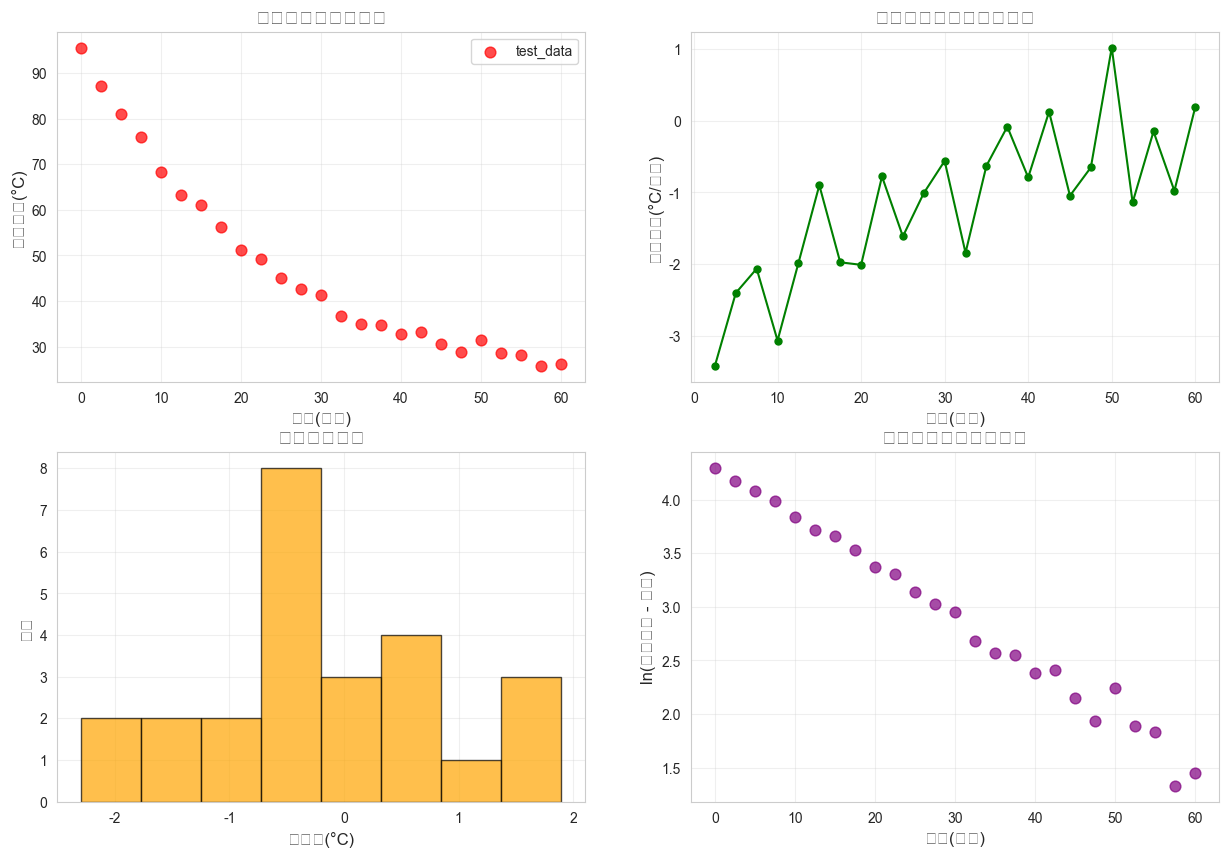

In [7]:
fig,axes = plt.subplots(2,2,figsize=(15,10))

# 原始数据散点图
axes[0,0].scatter(time_data, measured_temp, color='red', alpha=0.7, s=60, label='test_data')
axes[0,0].set_title('咖啡冷却温度散点图', fontsize=14)
axes[0,0].set_xlabel('时间(分钟)', fontsize=12)
axes[0,0].set_ylabel('测量温度(°C)', fontsize=12)
axes[0,0].grid(True, alpha=0.3)
axes[0,0].legend()


# 温度随时间的变化率
temp_diff = np.diff(measured_temp)
time_diff = np.diff(time_data)
cooling_rate = temp_diff / time_diff

axes[0,1].plot(time_data[1:], cooling_rate, 'o-', color='green', ms=5)
axes[0,1].set_title('咖啡冷却速率随时间变化', fontsize=14)
axes[0,1].set_xlabel('时间(分钟)', fontsize=12)
axes[0,1].set_ylabel('冷却速率(°C/分钟)', fontsize=12)
axes[0,1].grid(True, alpha=0.3)

# 测量误差分布
axes[1,0].hist(df['温度差'], bins=8, color='orange', alpha=0.7, edgecolor='black')
axes[1,0].set_title('测量误差分布', fontsize=14)
axes[1,0].set_xlabel('温度差(°C)', fontsize=12)
axes[1,0].set_ylabel('频次', fontsize=12)
axes[1,0].grid(True, alpha=0.3)

# 温度与时间的对数关系
axes[1,1].scatter(time_data, np.log(measured_temp - params[0]), color='purple', alpha=0.7, s=60)
axes[1,1].set_title('温度与时间的对数关系', fontsize=14)
axes[1,1].set_xlabel('时间(分钟)', fontsize=12)
axes[1,1].set_ylabel('ln(测量温度 - 室温)', fontsize=12)
axes[1,1].grid(True, alpha=0.3)

3.定义非线性回归模型

In [8]:
def newton_cooling_model(t, T_room, T_initial, k):
    '''
    牛顿冷却定律模型函数
    '''
    return T_room + (T_initial - T_room) * np.exp(-k * t)

def exponential_decay_model(t, a, b, c):
    '''
    指数衰减模型函数
    '''
    return a + b * np.exp(-c * t)

4.参数估计——多种方法比较

In [9]:
print('\n🔍 模型拟合与参数估计')
print('-'*40)

# 方法1：牛顿冷却定律
print("\n方法1:牛顿冷却定律拟合")

# 智能初值设定
T_room_init = min(measured_temp)  # 室温初值设定为测量温度的最小值
T_diff_init = max(measured_temp) - T_room_init  # 温度差初值设定为测量温度的最大值减去室温
k_init = 0.05  # 冷却系数初值设定为0.05(经验值)

initial_guess_1 = [T_room_init, T_diff_init, k_init]
print(f'初始猜测值： 室温: {T_room_init:.2f}, 温度差: {T_diff_init:.2f}, 冷却系数: {k_init:.4f}')

try:
    popt_1,pcov_1 = curve_fit(newton_cooling_model, time_data, measured_temp,p0=initial_guess_1,maxfev=10000)
    # 预测
    y_pred_1 = newton_cooling_model(time_data, *popt_1)
    # 计算评估指标
    r2_1 = r2_score(measured_temp, y_pred_1)
    rmse_1 = np.sqrt(mean_squared_error(measured_temp, y_pred_1))
    mae_1 = mean_absolute_error(measured_temp, y_pred_1)
    print(f'拟合参数: 室温: {popt_1[0]:.2f}, 温度差: {popt_1[1]:.2f}, 冷却系数: {popt_1[2]:.4f}')
    print(f'评估指标: R²: {r2_1:.4f}, RMSE: {rmse_1:.4f}, MAE: {mae_1:.4f}')
except Exception as e:
    print(f"拟合失败: {e}")


# 方法2：指数衰减模型
print("\n方法2:指数衰减模型拟合")

initial_guess_2 = [T_room_init, T_diff_init, k_init]

try:
    popt_2,pcov_2 = curve_fit(exponential_decay_model, time_data, measured_temp,p0=initial_guess_2, maxfev=10000)
    # 预测
    y_pred_2 = exponential_decay_model(time_data, *popt_2)
    # 计算评估指标
    r2_2 = r2_score(measured_temp, y_pred_2)
    rmse_2 = np.sqrt(mean_squared_error(measured_temp, y_pred_2))
    mae_2 = mean_absolute_error(measured_temp, y_pred_2)
    print(f'拟合参数: a: {popt_2[0]:.2f}, b: {popt_2[1]:.2f}, c: {popt_2[2]:.4f}')
    print(f'评估指标: R²: {r2_2:.4f}, RMSE: {rmse_2:.4f}, MAE: {mae_2:.4f}')
except Exception as e:
    print(f"拟合失败: {e}")


🔍 模型拟合与参数估计
----------------------------------------

方法1:牛顿冷却定律拟合
初始猜测值： 室温: 25.78, 温度差: 69.82, 冷却系数: 0.0500
拟合参数: 室温: 20.90, 温度差: 95.83, 冷却系数: 0.0445
评估指标: R²: 0.9975, RMSE: 1.0099, MAE: 0.8297

方法2:指数衰减模型拟合
拟合参数: a: 20.90, b: 74.92, c: 0.0445
评估指标: R²: 0.9975, RMSE: 1.0099, MAE: 0.8297


5.模型比较与可视化


📊 模型比较
----------------------------------------
T_diff:真实值=73.0°C,估计值=95.8°C (牛顿冷却定律), 74.9°C (指数衰减模型)
k:真实值=0.0450,估计值=0.0445 (牛顿冷却定律), 0.0445 (指数衰减模型)


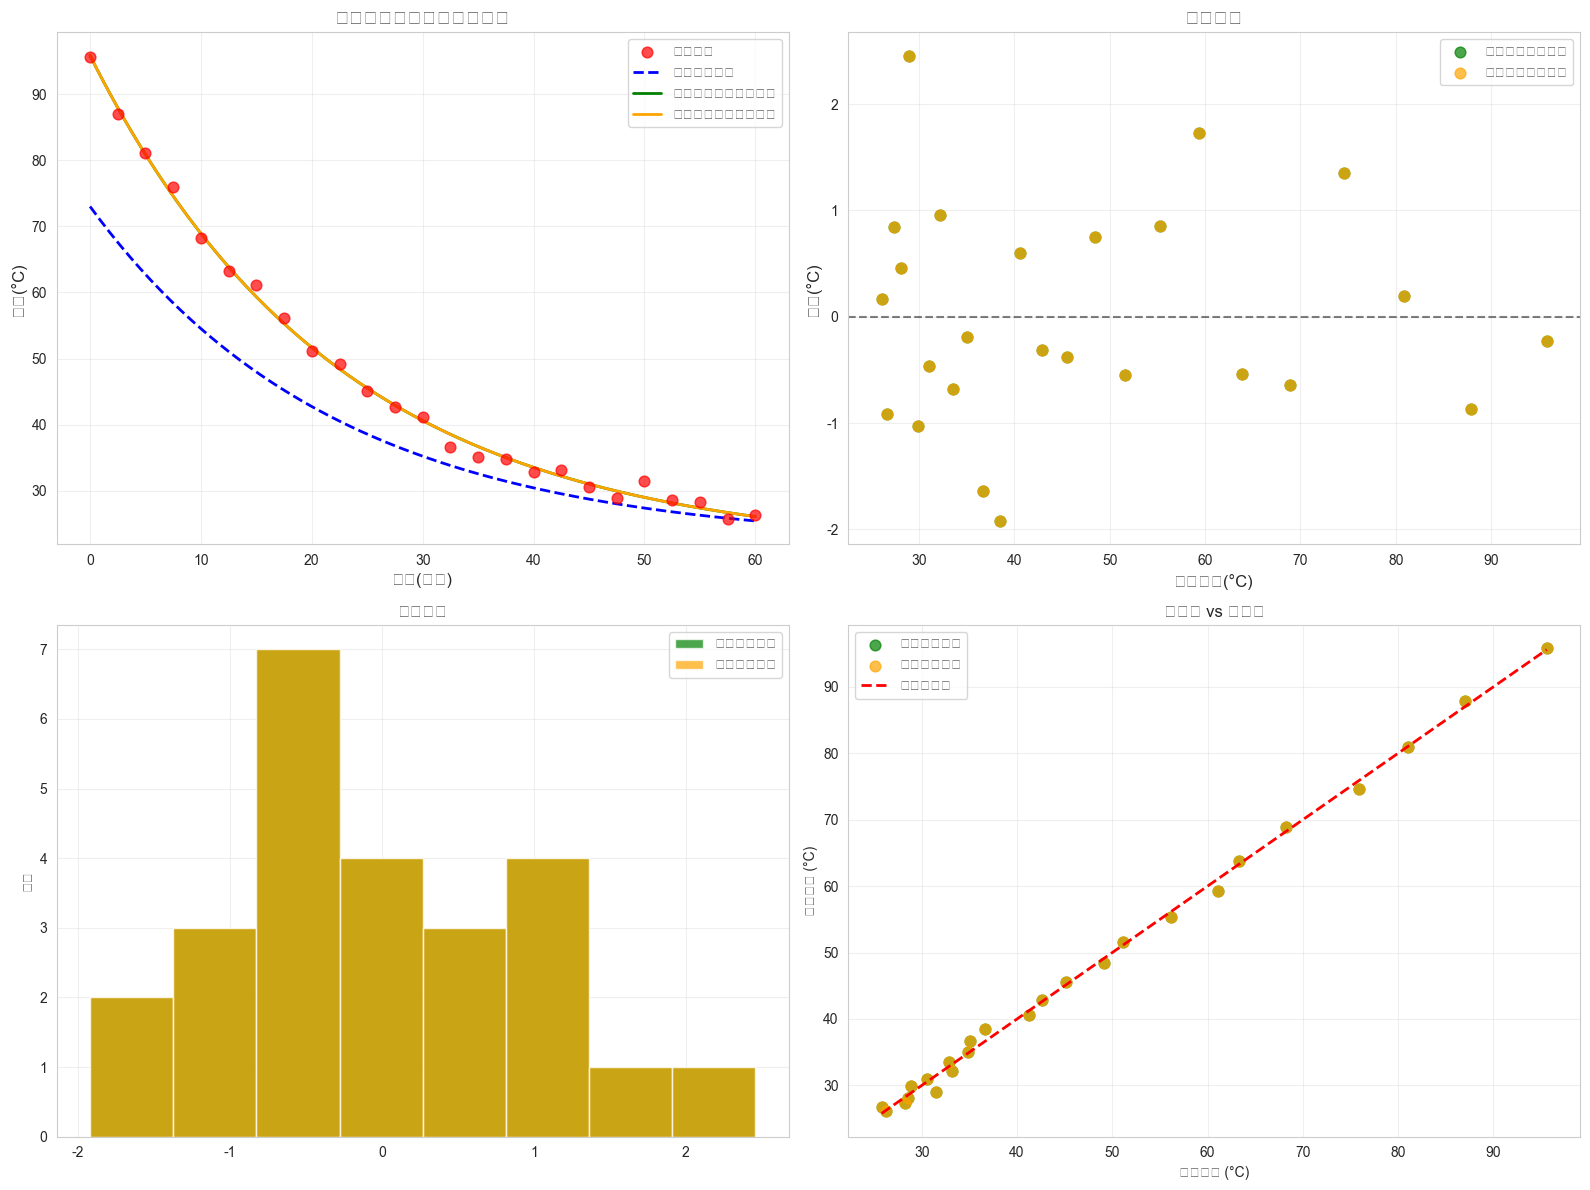

In [14]:

print("\n📊 模型比较")
print("-" * 40)

# 比较真实参数和模型参数
print(f'T_diff:真实值={params[1]-params[0]:.1f}°C,估计值={popt_1[1]:.1f}°C (牛顿冷却定律), {popt_2[1]:.1f}°C (指数衰减模型)')
print(f'k:真实值={params[2]:.4f},估计值={popt_1[2]:.4f} (牛顿冷却定律), {popt_2[2]:.4f} (指数衰减模型)')

# 创建详细的模型比较图
fig, axes = plt.subplots(2,2,figsize=(16,12))

# 拟合结果对比
time_plot = np.linspace(0,60,200)
y_true_plot = newton_cooling_model(time_plot,params[0],params[1]-params[0],params[2])
y_pred_plot_1 = newton_cooling_model(time_plot, *popt_1)
y_pred_plot_2 = exponential_decay_model(time_plot, *popt_2)

axes[0,0].scatter(time_data, measured_temp, color='red', alpha=0.7,s=60,label='测量数据', zorder=5)
axes[0,0].plot(time_plot,y_true_plot, color='blue',linewidth=2,label='真实温度曲线', linestyle='--')
axes[0,0].plot(time_plot,y_pred_plot_1, color='green',linewidth=2,label='牛顿冷却定律拟合曲线')
axes[0,0].plot(time_plot,y_pred_plot_2, color='orange',linewidth=2,label='指数衰减模型拟合曲线')
axes[0,0].set_title('咖啡冷却温度拟合结果对比', fontsize=14)
axes[0,0].set_xlabel('时间(分钟)', fontsize=12)
axes[0,0].set_ylabel('温度(°C)', fontsize=12)
axes[0,0].grid(True, alpha=0.3)
axes[0,0].legend()

# 残差分析
residuals_1 = measured_temp - y_pred_1
residuals_2 = measured_temp - y_pred_2
axes[0,1].scatter(y_pred_1, residuals_1, color='green',alpha=0.7,s=60,label='牛顿冷却定律残差')
axes[0,1].scatter(y_pred_2, residuals_2, color='orange',alpha=0.7,s=60,label='指数衰减模型残差')
axes[0,1].axhline(0, color='black', linestyle='--',alpha=0.5)
axes[0,1].set_title('残差分析', fontsize=14)
axes[0,1].set_xlabel('预测温度(°C)', fontsize=12)
axes[0,1].set_ylabel('残差(°C)', fontsize=12)
axes[0,1].grid(True, alpha=0.3)
axes[0,1].legend()

# 误差分析
axes[1,0].hist(residuals_1,bins=8,alpha=0.7,color='green',label='牛顿冷却模型')
axes[1,0].hist(residuals_2, bins=8, alpha=0.7, color='orange', label='指数衰减模型')
axes[1,0].set_title('残差分布')
axes[1, 0].set_ylabel('频次')
axes[1, 0].set_title('残差分布')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 预测vs比较
axes[1,1].scatter(measured_temp,y_pred_1,color='green',alpha=0.7,s=60,label='牛顿冷却模型')
axes[1,1].scatter(measured_temp,y_pred_2,color='orange',alpha=0.7,s=60,label='指数衰减模型')
axes[1, 1].plot([measured_temp.min(), measured_temp.max()], 
                [measured_temp.min(), measured_temp.max()], 
                'r--', linewidth=2, label='理想拟合线')
axes[1, 1].set_xlabel('实际温度 (°C)')
axes[1, 1].set_ylabel('预测温度 (°C)')
axes[1, 1].set_title('预测值 vs 实际值')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


6.模型检测

In [16]:
print("\n🔍 模型诊断")
print("-" * 40)

# 残差正态性检验
from scipy import stats

# Shapiro-Wilk正态性检验
stat_1, p_value_1 = stats.shapiro(residuals_1)
stat_2,p_value_2 = stats.shapiro(residuals_2)

print('残差正态性检验：')
print(f'牛顿冷却模型：统计量={stat_1:.4f},p值={p_value_1:.4f}')
print(f"指数衰减模型: 统计量={stat_2:.4f}, p值={p_value_2:.4f}")
print("注: p值>0.05表示残差服从正态分布")

# 残差自相关性检验
def durbin_waston_test(residuals):
    """Durbin-Watson检验统计量"""
    n = len(residuals)
    if n < 2:
        return None

    diff_residuals = np.diff(residuals)
    sum_square_diff = np.sum(diff_residuals ** 2)
    sum_square_residuals = np.sum(residuals ** 2)

    dw = sum_square_diff / sum_square_residuals
    return dw

dw_1 = durbin_waston_test(residuals_1)
dw_2 = durbin_waston_test(residuals_2)

print(f"\n残差自相关性检验 (Durbin-Watson):")
print(f"牛顿冷却模型: DW={dw_1:.4f}")
print(f"指数衰减模型: DW={dw_2:.4f}")
print("注: DW≈2表示无自相关，0<DW<2表示正自相关，2<DW<4表示负自相关")


🔍 模型诊断
----------------------------------------
残差正态性检验：
牛顿冷却模型：统计量=0.9766,p值=0.8100
指数衰减模型: 统计量=0.9766, p值=0.8100
注: p值>0.05表示残差服从正态分布

残差自相关性检验 (Durbin-Watson):
牛顿冷却模型: DW=2.0792
指数衰减模型: DW=2.0792
注: DW≈2表示无自相关，0<DW<2表示正自相关，2<DW<4表示负自相关


7.交叉验证

In [17]:
print("\n✅ 交叉验证")
print("-" * 40)

from sklearn.model_selection import KFold

def cross_validate_nonlinear(X, y, model_func, initial_guess, cv=5):
    """非线性模型的交叉验证"""
    kfold = KFold(n_splits=cv, shuffle=True, random_state=42)

    r2_scores = []
    rmse_scores = []

    for train_idx, test_idx in kfold.split(X):
        X_train,X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        try:
            # 模拟拟合
            popt, _ = curve_fit(model_func, X_train, y_train, p0=initial_guess, maxfev=10000)

            # 预测
            y_pred = model_func(X_test,*popt)

            # 计算指标
            r2 = r2_score(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            
            r2_scores.append(r2)
            rmse_scores.append(rmse)
        
        except RuntimeError:
            continue

        return np.array(r2_scores),np.array(rmse_scores)
    
# 对牛顿冷却模型进行交叉验证
r2_cv_1, rmse_cv_1 = cross_validate_nonlinear(time_data, measured_temp,newton_cooling_model,initial_guess_1)
print(f"牛顿冷却模型交叉验证结果:")
print(f"R²: {r2_cv_1.mean():.4f} ± {r2_cv_1.std():.4f}")
print(f"RMSE: {rmse_cv_1.mean():.2f} ± {rmse_cv_1.std():.2f} °C")


✅ 交叉验证
----------------------------------------
牛顿冷却模型交叉验证结果:
R²: 0.9991 ± 0.0000
RMSE: 0.74 ± 0.00 °C


8.预测未来温度


🔮 未来温度预测
----------------------------------------
未来温度预测结果:
    时间(分钟)   预测温度(°C)  95%置信区间下界  95%置信区间上界    预测区间宽度
0     60.0  26.088593  24.271050  28.162593  3.891543
1     62.5  25.542634  23.779709  27.599294  3.819585
2     65.0  25.054175  23.321313  27.090379  3.769066
3     67.5  24.617159  22.911060  26.614157  3.703097
4     70.0  24.226169  22.541322  26.176302  3.634980
5     72.5  23.876357  22.199164  25.820612  3.621448
6     75.0  23.563387  21.917598  25.500131  3.582533
7     77.5  23.283378  21.617392  25.201925  3.584533
8     80.0  23.032859  21.398456  24.957491  3.559034
9     82.5  22.808724  21.203707  24.723890  3.520184
10    85.0  22.608194  21.006812  24.523985  3.517173
11    87.5  22.428784  20.810294  24.342764  3.532470
12    90.0  22.268269  20.644521  24.179876  3.535355


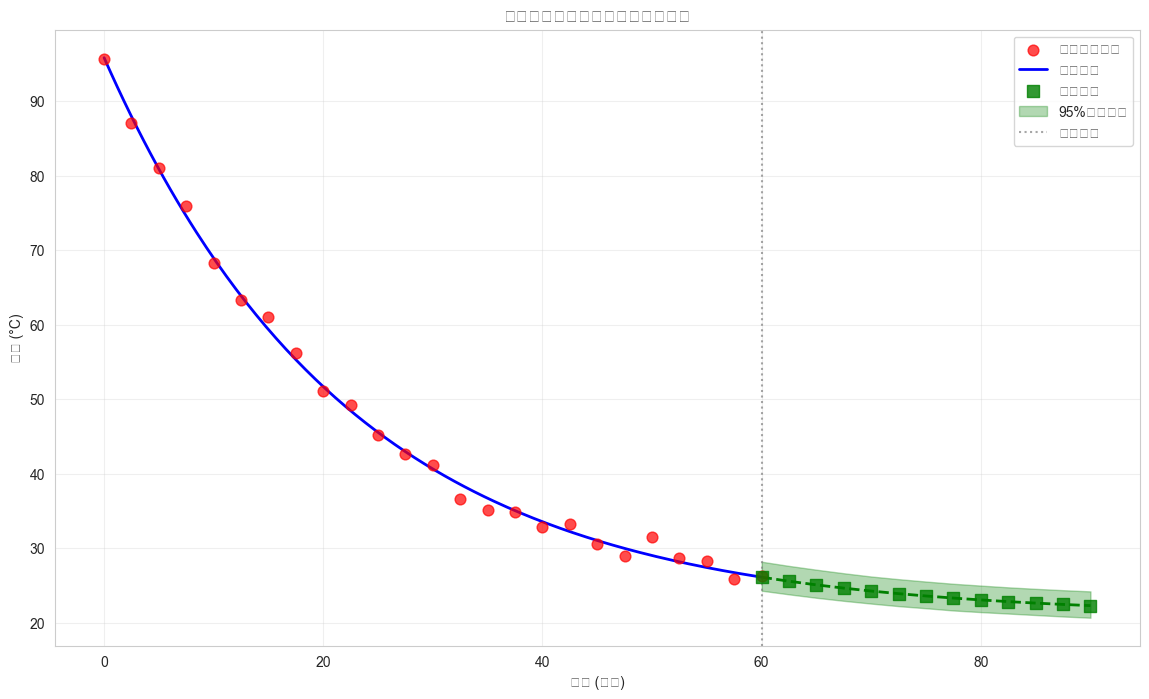


🔬 物理意义解释
----------------------------------------
估计的室温: 20.9°C
估计的初始温度: 116.7°C
估计的冷却系数: 0.0445 min⁻¹
冷却半衰期: 15.6分钟
降到25.9°C需要: 66.3分钟

📋 模型总结报告
🎯 模型性能:
   • 拟合优度 (R²): 0.9975
   • 均方根误差 (RMSE): 1.01°C
   • 平均绝对误差 (MAE): 0.83°C
   • 交叉验证 R²: 0.9991 ± 0.0000

📊 参数估计:
   • 室温: 20.9 ± 0.9°C
   • 初始温度: 116.7 ± 0.7°C
   • 冷却系数: 0.0445 ± 0.0016 min⁻¹

🔍 模型诊断:
   • 残差正态性: ✓ (p=0.8100)
   • 自相关性: ✓ (DW=2.0792)

🌟 实际应用:
   • 冷却半衰期: 15.6分钟
   • 适饮温度时间: 66.3分钟
   • 模型适用范围: 0-90分钟

💡 建议:
   • 模型拟合优秀，可用于实际预测
   • 残差服从正态分布，模型假设合理

案例1分析完成！


In [22]:
print("\n🔮 未来温度预测")
print("-" * 40)

# 预测未来30分钟的温度
future_time = np.linspace(60,90,13)  # 60-90分钟，每2.5分钟一个点
future_time_pred = newton_cooling_model(future_time, *popt_1)

# 计算预测区间（基于参数不确定性）
param_std = np.sqrt(np.diag(pcov_1)) #协方差矩阵对角线元素开方得到参数标准差
n_simulations = 1000

# 蒙特卡洛模拟预测区间
future_predictions = []
for _ in range(n_simulations):
    # 从参数的正态分布中采样
    sampled_params = np.random.normal(popt_1, param_std)
    pred = newton_cooling_model(future_time, *sampled_params)
    future_predictions.append(pred)

future_predictions = np.array(future_predictions)
pred_lower = np.percentile(future_predictions,2.5,axis=0)  # 95%置信区间下界
pred_higher = np.percentile(future_predictions,97.5,axis=0)   # 95%置信区间上界

# 创建预测结果表
pred_df = pd.DataFrame({
    '时间(分钟)': future_time,
    '预测温度(°C)': future_time_pred,
    '95%置信区间下界': pred_lower,
    '95%置信区间上界': pred_higher,
    '预测区间宽度': pred_higher - pred_lower
})

print("未来温度预测结果:")
print(pred_df)

# 可视化预测结果
plt.figure(figsize=(14, 8))

# 历史数据
plt.scatter(time_data, measured_temp, color='red', alpha=0.7, s=60, label='历史测量数据', zorder=5)
plt.plot(time_plot, y_pred_plot_1, color='blue', linewidth=2, label='拟合曲线')

# 预测数据
plt.scatter(future_time, future_time_pred, color='green', alpha=0.8, s=80, 
           marker='s', label='未来预测', zorder=5)
plt.fill_between(future_time, pred_lower, pred_higher, alpha=0.3, color='green', 
                label='95%置信区间')

# 连接线
plt.plot(future_time, future_time_pred, color='green', linewidth=2, linestyle='--')

plt.axvline(x=60, color='gray', linestyle=':', alpha=0.7, label='预测起点')
plt.xlabel('时间 (分钟)')
plt.ylabel('温度 (°C)')
plt.title('咖啡冷却温度预测（含置信区间）')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 9. 物理意义解释
print("\n🔬 物理意义解释")
print("-" * 40)

estimated_T_room = popt_1[0]
estimated_T_initial = popt_1[0] + popt_1[1]
estimated_k = popt_1[2]

print(f"估计的室温: {estimated_T_room:.1f}°C")
print(f"估计的初始温度: {estimated_T_initial:.1f}°C")
print(f"估计的冷却系数: {estimated_k:.4f} min⁻¹")

# 计算半衰期（温度差减半所需时间）
half_life = np.log(2) / estimated_k
print(f"冷却半衰期: {half_life:.1f}分钟")

# 计算到达特定温度的时间
def time_to_reach_temp(target_temp, T_room, T_initial, k):
    """计算到达目标温度所需的时间"""
    if target_temp <= T_room or target_temp >= T_initial:
        return None
    return -np.log((target_temp - T_room) / (T_initial - T_room)) / k

# 计算降到室温+5°C所需的时间
time_to_warm = time_to_reach_temp(estimated_T_room + 5, estimated_T_room, estimated_T_initial, estimated_k)
print(f"降到{estimated_T_room + 5:.1f}°C需要: {time_to_warm:.1f}分钟")

# 10. 总结报告
print("\n📋 模型总结报告")
print("=" * 60)

print("🎯 模型性能:")
print(f"   • 拟合优度 (R²): {r2_1:.4f}")
print(f"   • 均方根误差 (RMSE): {rmse_1:.2f}°C")
print(f"   • 平均绝对误差 (MAE): {mae_1:.2f}°C")
print(f"   • 交叉验证 R²: {r2_cv_1.mean():.4f} ± {r2_cv_1.std():.4f}")

print("\n📊 参数估计:")
print(f"   • 室温: {estimated_T_room:.1f} ± {param_std[0]:.1f}°C")
print(f"   • 初始温度: {estimated_T_initial:.1f} ± {param_std[1]:.1f}°C")
print(f"   • 冷却系数: {estimated_k:.4f} ± {param_std[2]:.4f} min⁻¹")

print("\n🔍 模型诊断:")
print(f"   • 残差正态性: {'✓' if p_value_1 > 0.05 else '✗'} (p={p_value_1:.4f})")
print(f"   • 自相关性: {'✓' if abs(dw_1 - 2) < 0.5 else '✗'} (DW={dw_1:.4f})")

print("\n🌟 实际应用:")
print(f"   • 冷却半衰期: {half_life:.1f}分钟")
print(f"   • 适饮温度时间: {time_to_warm:.1f}分钟")
print(f"   • 模型适用范围: 0-90分钟")

print("\n💡 建议:")
if r2_1 > 0.95:
    print("   • 模型拟合优秀，可用于实际预测")
else:
    print("   • 模型拟合良好，但需要更多数据验证")

if p_value_1 > 0.05:
    print("   • 残差服从正态分布，模型假设合理")
else:
    print("   • 残差不服从正态分布，考虑模型改进")

print("\n" + "=" * 60)
print("案例1分析完成！")
print("=" * 60)